## Non-standard primordial power spectrum (wavepacket oscillation)

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, platform, os
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
import camb
from camb import model, initialpower
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))

Using CAMB 1.5.9 installed at /mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/CMBFeatureNet/CAMB/camb


class: <CAMBparams>
 WantCls = True
 WantTransfer = False
 WantScalars = True
 WantTensors = False
 WantVectors = False
 WantDerivedParameters = True
 Want_cl_2D_array = True
 Want_CMB = True
 Want_CMB_lensing = True
 DoLensing = True
 NonLinear = NonLinear_none
 Transfer: <TransferParams>
   high_precision = False
   accurate_massive_neutrinos = False
   kmax = 0.9
   k_per_logint = 0
   PK_num_redshifts = 1
   PK_redshifts = [0.0]
 want_zstar = False
 want_zdrag = False
 min_l = 2
 max_l = 2657
 max_l_tensor = 600
 max_eta_k = 6642.5
 max_eta_k_tensor = 1200.0
 ombh2 = 0.02237
 omch2 = 0.12
 omk = 0.0
 omnuh2 = 0.000644866570625114
 H0 = 67.4
 TCMB = 2.7255
 YHe = 0.24585548197552395
 num_nu_massless = 2.0293333333333337
 num_nu_massive = 1
 nu_mass_eigenstates = 1
 share_delta_neff = False
 nu_mass_degeneracies = [1.0146666666666666]
 nu_mass_fractions = [1.0]
 nu_mass_numbers = [1]
 InitPower: <SplinedInitialPower>
   effective_ns_for_nonlinear = 0.96
 Recomb: <Recfast>
   min_a_ev

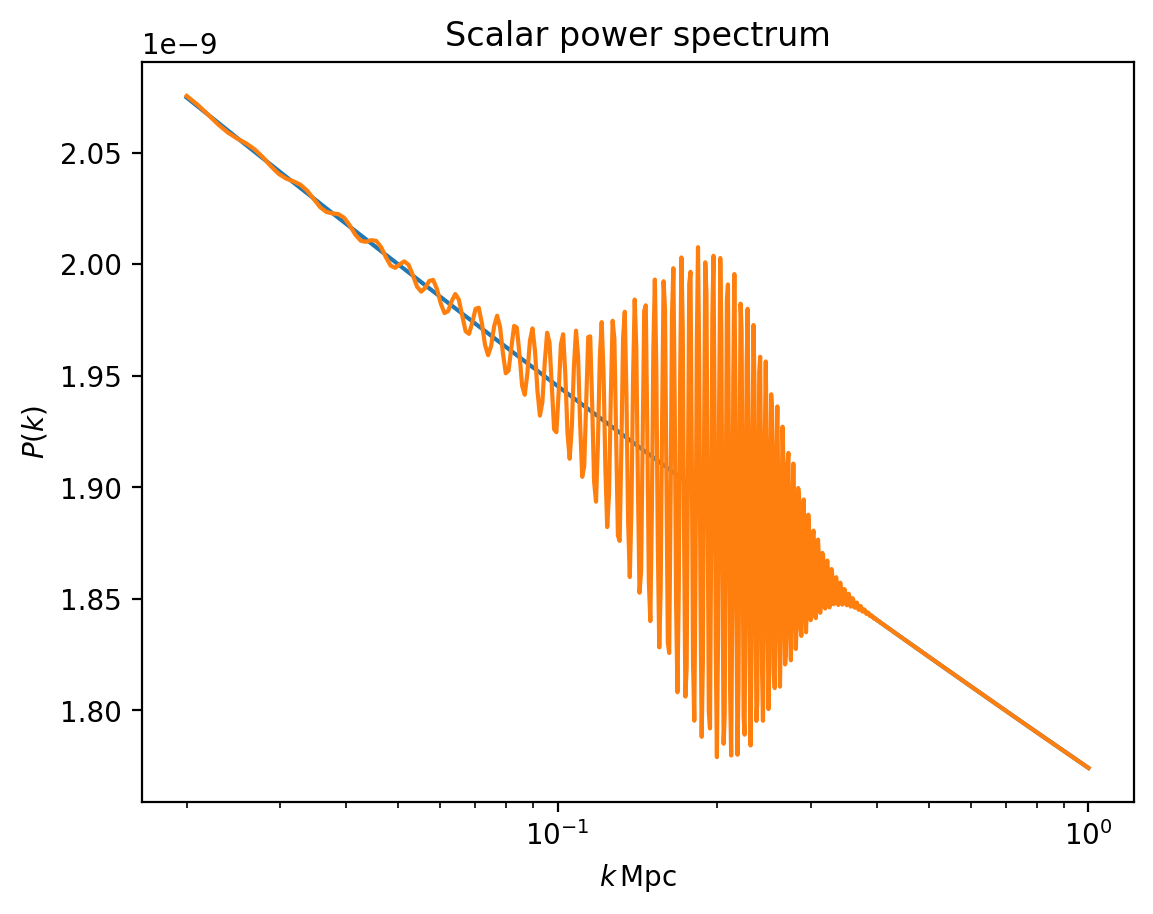

<Figure size 640x480 with 0 Axes>

In [2]:
from CMBFeatureNet import PK

params = camb.set_params(H0=67.4, ombh2=0.02237, omch2=0.1200, mnu=0.06, omk=0, tau=0.0544,  
                    As=2.1e-9, ns=0.9649, halofit_version='mead', lmax=2507)
freq = 1000
ks = np.linspace(0.02,1,1000)
pk1 = 2e-9*(ks/0.05)**(0.96-1)
pk2 = PK(ks,2e-9, 0.96,0.0599,freq, 0.08, 0.2,0)
plt.semilogx(ks,pk1)
plt.semilogx(ks,pk2)
plt.ylabel('$P(k)$')
plt.xlabel(r'$k\, {\rm Mpc}$');
plt.title('Scalar power spectrum')
plt.figure()

params.set_initial_power_function(PK, args=(2e-9, 0.96,0.0599, freq, 0.08, 0.2,0),
                               effective_ns_for_nonlinear=0.96)

In [3]:
#Now compute C_l and compare
pars = camb.CAMBparams()
pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122, tau=0.06)
lmax=2507
pars.set_for_lmax(lmax,lens_potential_accuracy=1)

#For comparison, standard power law
pars.InitPower.set_params(As=2e-9, ns=0.96)
results = camb.get_results(pars)
cl_unlensed=results.get_unlensed_scalar_cls(CMB_unit ='muK')
cl=results.get_lensed_scalar_cls(CMB_unit ='muK')

#Note that if you have sharp features or fine oscillations, you may need 
#increase accuracy to sample them well. e.g. let's try increasing the frequency

#Default accuracy
pars.Accuracy.lSampleBoost = 1
pars.Accuracy.IntkAccuracyBoost =1
pars.Accuracy.SourcekAccuracyBoost =1

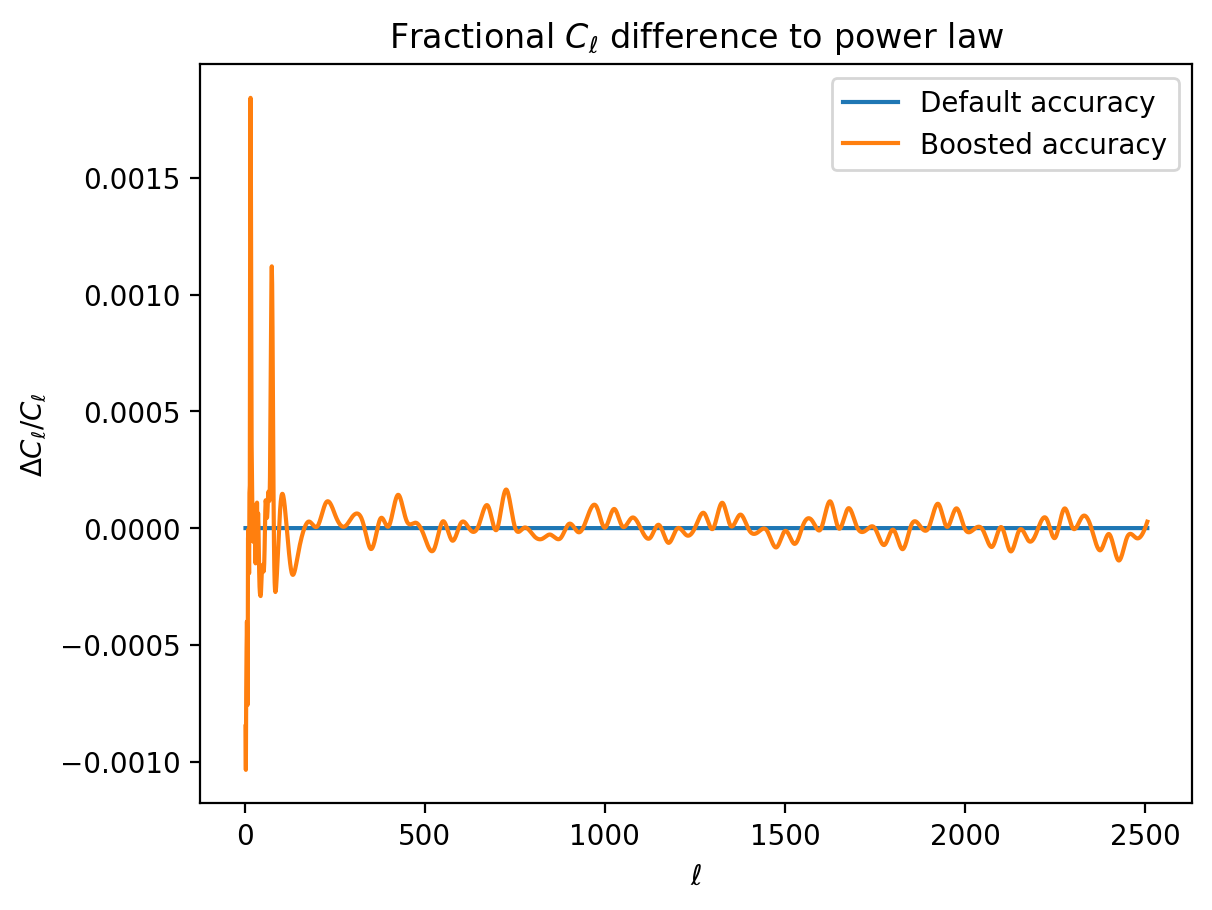

In [4]:
results2 = camb.get_results(pars)
cl_unlensed2=results2.get_unlensed_scalar_cls(CMB_unit ='muK')

#need to increase default sampling in ell to see features smaller than peaks reliably
pars.Accuracy.lSampleBoost = 2
#may also need to sample k more densely when computing C_l from P(k)
pars.Accuracy.IntkAccuracyBoost = 2 

results3 = camb.get_results(pars)
cl_unlensed3=results3.get_unlensed_scalar_cls(CMB_unit ='muK')
cl3=results3.get_lensed_scalar_cls(CMB_unit ='muK')

ls = np.arange(2,lmax)
plt.plot(ls,(cl_unlensed2[2:lmax,0]/cl_unlensed[2:lmax,0]-1))
plt.plot(ls,(cl_unlensed3[2:lmax,0]/cl_unlensed[2:lmax,0]-1))

plt.xlabel(r'$\ell$')
plt.ylabel(r'$\Delta C_\ell/C_\ell$')
plt.title(r'Fractional $C_\ell$ difference to power law')
plt.legend(['Default accuracy','Boosted accuracy']);

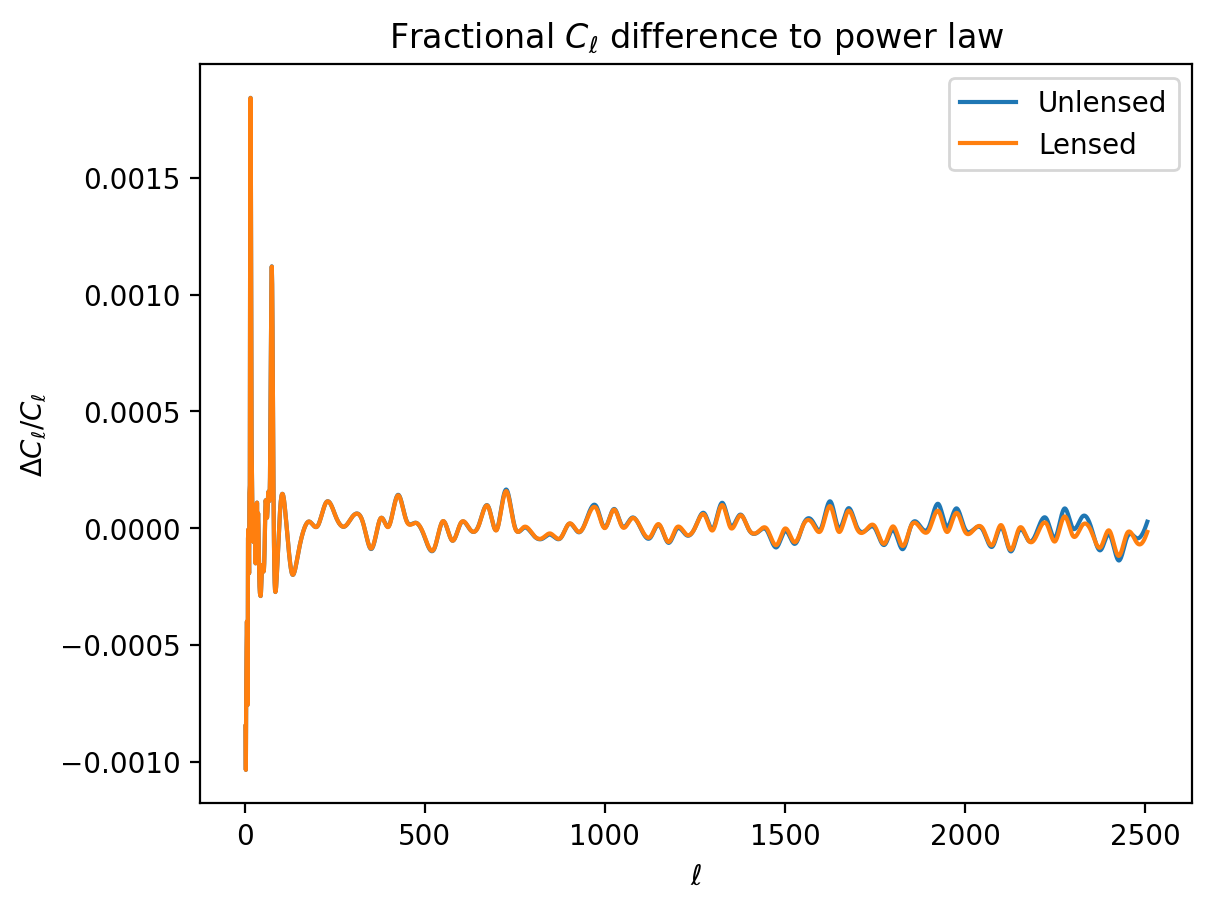

In [5]:
#Note that lensing washes out small features on small scales
plt.plot(ls,(cl_unlensed3[2:lmax,0]/cl_unlensed[2:lmax,0]-1))
plt.plot(ls,(cl3[2:lmax,0]/cl[2:lmax,0]-1))
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\Delta C_\ell/C_\ell$')
plt.legend(['Unlensed','Lensed'])
plt.title(r'Fractional $C_\ell$ difference to power law');